In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure plots show inline and look clean
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Setup complete! Ready to analyze RCM data.")

Setup complete! Ready to analyze RCM data.


In [2]:
# Load your dataset
df=pd.read_csv(r"C:\Users\Sujin Andro\OneDrive\Desktop\movies\rcm claim\claims_main.csv")

In [3]:
#1. Datetime conversion
df['claim_submission_date'] = pd.to_datetime(df['claim_submission_date'], errors='coerce')

# 2. Text normalization
df['outcome'] = df['outcome'].astype(str).str.strip().str.title()
df['denial_category'] = df['denial_category'].fillna('Unknown')
df['denial_reason_code'] = df['denial_reason_code'].fillna('N/A')

# 3. Handle Prior Auth flags
true_vals = ['true', '1', 'yes', 'y']
df['prior_auth_required_flag'] = df['prior_auth_required'].astype(str).str.lower().isin(true_vals)
df['prior_auth_obtained_flag'] = df['prior_auth_obtained'].astype(str).str.lower().isin(true_vals)

# Missing auth flag
df['missing_prior_auth'] = df['prior_auth_required_flag'] & ~df['prior_auth_obtained_flag']

df.head(3)

,claim_id,claim_submission_date,claim_year,claim_quarter,payer_type,provider_specialty,place_of_service_code,place_of_service_desc,cpt_code,modifier,...,claim_amount_usd,outcome,denial_reason_code,denial_category,dataset_version,synthetic_flag,generation_date,prior_auth_required_flag,prior_auth_obtained_flag,missing_prior_auth
0,e46071e9-0fe0-42d8-ab46-dbb0c48341c4,2022-04-22,2022,Q2,Commercial_PPO,Emergency_Medicine,23,Emergency_Room,99283,NaN,...,656.22,Denied,CO-4,coding_error,2.00,True,2026-04-28,False,False,False
1,a641a4ce-38d4-4467-a9d3-d4970735ecc0,2022-07-24,2022,Q3,Medicare_FFS,Internal_Medicine,11,Office,99215,25,...,332.89,Denied,CO-97,duplicate,2.00,True,2026-04-28,False,False,False
2,2bd53273-5f36-46ad-b777-0035afd1e2e7,2022-08-24,2022,Q3,Commercial_EPO,Cardiology,2,Telehealth,93000,NaN,...,185.97,Denied,CO-4,bundling,2.00,True,2026-04-28,False,False,False


In [4]:
#Executive Summary & KPIs
#What it does: Calculates total billed revenue, overall denial rate, and financial revenue lost.

total_claims = len(df)
total_billed = df['claim_amount_usd'].sum()

denied_df = df[df['outcome'] == 'Denied']
total_denied_claims = len(denied_df)
total_denied_usd = denied_df['claim_amount_usd'].sum()
denial_rate = (total_denied_claims / total_claims) * 100

print("=" * 45)
print("        EXECUTIVE RCM METRICS          ")
print("=" * 45)
print(f"Total Claims Processed : {total_claims:,}")
print(f"Total Billed Amount    : ${total_billed:,.2f}")
print(f"Total Denied Claims    : {total_denied_claims:,}")
print(f"Total Denied Value     : ${total_denied_usd:,.2f}")
print(f"Overall Denial Rate    : {denial_rate:.2f}%")

        EXECUTIVE RCM METRICS          
Total Claims Processed : 120,000
Total Billed Amount    : $266,829,762.19
Total Denied Claims    : 33,664
Total Denied Value     : $74,132,368.07
Overall Denial Rate    : 28.05%


C:\Users\Sujin Andro\AppData\Local\Temp\ipykernel_16640\1625599251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=denial_summary, x='total_denied_usd', y='denial_category', palette='Blues_r')


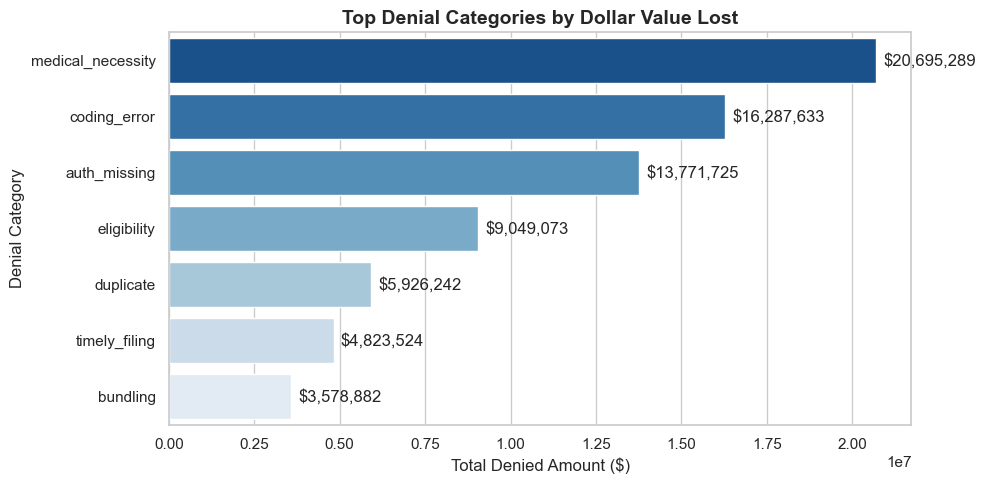

,denial_category,denied_claims,total_denied_usd
0,medical_necessity,9444,20695289.48
1,coding_error,7344,16287632.87
2,auth_missing,6140,13771724.75
3,eligibility,4084,9049072.75
4,duplicate,2645,5926242.02
5,timely_filing,2315,4823524.07
6,bundling,1692,3578882.13


In [5]:
#Top Denial Categories (Table + Plot)
# Grouping top denial categories
denial_summary = denied_df.groupby('denial_category').agg(
    denied_claims=('claim_id', 'count'),
    total_denied_usd=('claim_amount_usd', 'sum')
).sort_values(by='total_denied_usd', ascending=False).reset_index()

# Plotting directly in Jupyter
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=denial_summary, x='total_denied_usd', y='denial_category', palette='Blues_r')
plt.title('Top Denial Categories by Dollar Value Lost', fontsize=14, fontweight='bold')
plt.xlabel('Total Denied Amount ($)', fontsize=12)
plt.ylabel('Denial Category', fontsize=12)

# Add dollar labels to bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'${width:,.0f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

denial_summary

In [6]:
#Prior Auth Non-Compliance Analysis
# Filter for claims where prior auth was mandatory
auth_df = df[df['prior_auth_required_flag']].groupby('provider_specialty').agg(
    total_auth_required=('claim_id', 'count'),
    missing_auth_count=('missing_prior_auth', 'sum'),
    denied_usd=('claim_amount_usd', lambda x: x[df.loc[x.index, 'outcome'] == 'Denied'].sum())
).reset_index()

auth_df['missing_auth_pct'] = (auth_df['missing_auth_count'] / auth_df['total_auth_required']) * 100
auth_df = auth_df.sort_values(by='missing_auth_pct', ascending=False)

# Display styled table in Jupyter
auth_df.style.format({
    'total_auth_required': '{:,}',
    'missing_auth_count': '{:,}',
    'denied_usd': '${:,.2f}',
    'missing_auth_pct': '{:.2f}%'
}).background_gradient(subset=['missing_auth_pct'], cmap='Reds')

,provider_specialty,total_auth_required,missing_auth_count,denied_usd,missing_auth_pct
3,Gastroenterology,"2,292",346,"$1,890,867.65",15.10%
5,Neurology,"4,163",610,"$2,061,193.78",14.65%
10,Primary_Care,"2,236",317,"$167,330.68",14.18%
1,Cardiology,"5,415",758,"$9,208,950.44",14.00%
0,Behavioral_Health,"2,931",409,"$201,232.57",13.95%
8,Orthopedic_Surgery,"6,308",875,"$20,420,723.99",13.87%
7,Oncology,"6,431",890,"$5,765,018.81",13.84%
6,Obstetrics_Gynecology,"3,860",530,"$8,234,273.68",13.73%
12,Radiology,"6,101",834,"$3,458,303.55",13.67%
4,Internal_Medicine,"4,531",613,"$364,568.62",13.53%


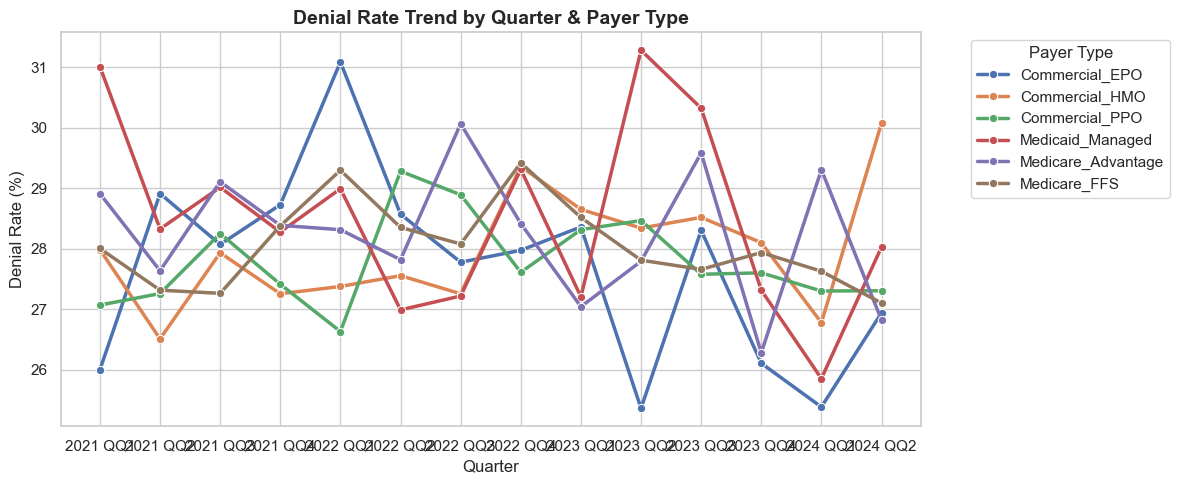

In [7]:
#Quarterly Denial Trend Analysis
quarterly = df.groupby(['claim_year', 'claim_quarter', 'payer_type']).agg(
    total_claims=('claim_id', 'count'),
    denied_claims=('claim_id', lambda x: (df.loc[x.index, 'outcome'] == 'Denied').sum())
).reset_index()

quarterly['denial_rate'] = (quarterly['denied_claims'] / quarterly['total_claims']) * 100
quarterly['period'] = quarterly['claim_year'].astype(str) + ' Q' + quarterly['claim_quarter'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=quarterly, x='period', y='denial_rate', hue='payer_type', marker='o', linewidth=2.5)
plt.title('Denial Rate Trend by Quarter & Payer Type', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Denial Rate (%)', fontsize=12)
plt.legend(title='Payer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
#Export Summary Data for Portfolio
denial_summary.to_csv('processed_denial_summary.csv', index=False)
auth_df.to_csv('processed_prior_auth_specialty.csv', index=False)
quarterly.to_csv('processed_quarterly_trends.csv', index=False)

print("All summary tables exported as CSVs in your Jupyter working directory!")

All summary tables exported as CSVs in your Jupyter working directory!
